In [61]:
import torch
from torch_geometric.nn import radius_graph
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from math import sqrt


# ============================================================
# Periodic neighbor graph
# ============================================================

def radius_graph_pbc(
    x,
    r_cutoff,
    L,
    max_num_neighbors=64,
):
    """
    Periodic radius graph for a 2D rectangular/square box.

    Parameters
    ----------
    x : (N, 2) tensor
        Particle positions in [0, L).
    r_cutoff : float
        Search radius.
    L : float or (2,) tensor
        Box size.
    max_num_neighbors : int
        Maximum number of neighbors per particle.

    Returns
    -------
    i : (E,) tensor
        Target particle indices.
    j : (E,) tensor
        Neighbor particle indices.
    """

    N, d = x.shape
    assert d == 2

    device = x.device
    dtype = x.dtype

    L = torch.as_tensor(L, device=device, dtype=dtype)
    if L.ndim == 0:
        L = L.repeat(d)

    shifts = torch.tensor(
        [
            [-1, -1], [-1,  0], [-1,  1],
            [ 0, -1], [ 0,  0], [ 0,  1],
            [ 1, -1], [ 1,  0], [ 1,  1],
        ],
        device=device,
        dtype=dtype,
    ) * L

    # Periodic copies: (9N, 2)
    x_ext = (
        x[None, :, :] + shifts[:, None, :]
    ).reshape(-1, d)

    # Maps each image back to its original particle.
    original_index = torch.arange(
        N,
        device=device,
    ).repeat(9)

    edge_index = radius_graph(
        x_ext,
        r=r_cutoff,
        loop=False,
        max_num_neighbors=max_num_neighbors,
        flow="source_to_target",
    )

    src, dst = edge_index

    # The fourth image block is the central simulation box.
    central_start = 4 * N
    central_end = 5 * N

    keep = (
        (dst >= central_start)
        & (dst < central_end)
    )

    src = src[keep]
    dst = dst[keep]

    # Target particle in central box.
    i = dst - central_start

    # Map source image back to original particle.
    j = original_index[src]

    # Remove self-interaction.
    keep = i != j

    return i[keep], j[keep]


# ============================================================
# Parameters
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

N = 4096
L = 128.0

num_steps = 50_000
dt = 0.01

num_initial_infected = N // 2

# Physical interaction distance
r_cutoff = 1.0

# Verlet-list skin
skin = 0.25
r_list = r_cutoff + skin

graph_update_every = 10
max_num_neighbors = 32

# Active speeds
v0_plus = 1.0
v0_minus = 0.1

# Rotational diffusion
D_plus = 1.0
D_minus = 0.1

# Recovery rate
recovery_beta = 0.5


# ============================================================
# Initial conditions
# ============================================================

x = torch.rand(
    N, 2,
    device=device,
) * L

theta = torch.rand(
    N,
    device=device,
) * (2 * torch.pi)

infected = torch.zeros(
    N,
    dtype=torch.bool,
    device=device,
)

infected[
    torch.randperm(N, device=device)[
        :num_initial_infected
    ]
] = True


# ============================================================
# Initial Verlet list
# ============================================================

i_list, j_list = radius_graph_pbc(
    x,
    r_cutoff=r_list,
    L=L,
    max_num_neighbors=max_num_neighbors,
)


# Exact recovery probability for one time step
p_recovery = 1.0 - torch.exp(
    torch.tensor(
        -recovery_beta * dt,
        device=device,
    )
)

In [62]:
# ============================================================
# Simulation
# ============================================================

pbar = tqdm(range(num_steps))

for step in pbar:

    # --------------------------------------------------------
    # Rebuild Verlet neighbor list
    # --------------------------------------------------------

    if step % graph_update_every == 0:

        i_list, j_list = radius_graph_pbc(
            x,
            r_cutoff=r_list,
            L=L,
            max_num_neighbors=max_num_neighbors,
        )

    # --------------------------------------------------------
    # Exact current distances for candidate pairs
    # --------------------------------------------------------

    rij = x[j_list] - x[i_list]

    # minimum-image convention
    rij -= L * torch.round(rij / L)

    r2 = (rij * rij).sum(dim=-1)

    contact = r2 < r_cutoff**2

    i = i_list[contact]
    j = j_list[contact]

    # --------------------------------------------------------
    # SIS dynamics
    # --------------------------------------------------------

    infected_old = infected.clone()

    num_infected_neighbors = torch.zeros(
        N,
        device=device,
    )

    num_infected_neighbors.index_add_(
        0,
        i,
        infected_old[j].to(x.dtype),
    )

    # Infection is instantaneous upon contact with >=1
    # infected particle.
    new_infections = (
        (~infected_old)
        & (num_infected_neighbors > 0)
    )

    # Poisson recovery
    new_recoveries = (
        infected_old
        & (
            torch.rand(N, device=device)
            < p_recovery
        )
    )

    infected = (
        (infected_old | new_infections)
        & ~new_recoveries
    )

    # --------------------------------------------------------
    # Rotational diffusion
    # --------------------------------------------------------

    D = torch.where(
        infected,
        D_plus,
        D_minus,
    )

    theta += (
        torch.sqrt(2.0 * D * dt)
        * torch.randn_like(theta)
    )

    # Optional: keep angles bounded.
    theta.remainder_(2 * torch.pi)

    # --------------------------------------------------------
    # Active motion
    # --------------------------------------------------------

    speed = torch.where(
        infected,
        v0_plus,
        v0_minus,
    )

    direction = torch.stack(
        [
            torch.cos(theta),
            torch.sin(theta),
        ],
        dim=-1,
    )

    x += (
        speed[:, None]
        * direction
        * dt
    )

    # Periodic boundaries
    x.remainder_(L)

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if step % 10 == 0:
        pbar.set_description(
            f"Step {step} | "
            f"Infected {infected.sum().item()}"
        )


# ============================================================
# Back to CPU
# ============================================================

x = x.cpu()
theta = theta.cpu()
infected = infected.cpu()

  0%|          | 0/50000 [00:00<?, ?it/s]

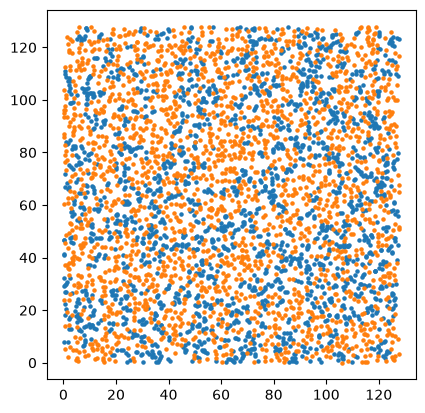

In [64]:
plt.scatter(x[infected, 0], x[infected, 1], s=5)
plt.scatter(x[~infected, 0], x[~infected, 1], s=5)
plt.gca().set_aspect('equal')
plt.show()